In [1]:
import numpy as np
import matplotlib.pyplot as plt
import EFC_learningfMRI.globals as gl
import PcmPy as pcm
import pandas as pd
from scipy.stats import linregress
import os
import itertools
import seaborn as sb
import statsmodels.formula.api as smf
from EFC_learningfMRI.util import add_behav_pair_diff, ttest_im_sess
from EFC_learningfMRI.vis import plot_im_sess

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


In [2]:
# Y: distance between trained chord pairs and untrained chord pairs
# X: Difference between 

H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
dist  = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist  = dist[(dist.Hem==H) & (dist.chord.isin(['trained', 'untrained']))]
measX = ['ET', 'MD', 'force_abs', 'force_der', 'force_der_peak']
force = pd.read_csv(os.path.join(gl.baseDir, gl.behavDir, f'force.success.tsv'), sep='\t')
diff  = add_behav_pair_diff(dist, measures=measX, behav=force)

betas = []
diff[['crossnobis_res', 'theta_res', ]] = np.nan
for sn in diff.sn.unique():
    for roi in rois:
        mask   = (diff.sn == sn) & (diff.roi==roi)
        diff_s = diff[mask]
        predX  = diff_s[['MD']].to_numpy()
        X      = np.c_[predX, np.ones(diff_s.shape[0])]
        Y      = diff_s[['crossnobis', 'theta']].to_numpy()
        B      = (np.linalg.pinv(X) @ Y)

        diff.loc[mask, ['crossnobis_res', 'theta_res']] = Y - X @ B

        #betas.append(pd.DataFrame({'MD': B[0, :], 'force_abs': B[1, :], 'intercept': B[2, :], 'metric': ['crossnobis', 'theta'], 'sn': sn, 'roi': roi}))

diff_chord_sess = diff.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

# betas = pd.concat(betas, ignore_index=True)

hue_order = ['trained', 'untrained']
palette   = ['red', 'blue']

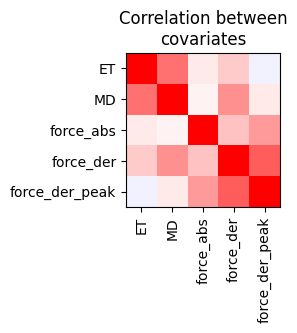

In [3]:
corrX = diff[measX].corr()

fig, ax = plt.subplots(figsize=(2, 2))

ax.imshow(corrX, vmin=-1, vmax=1, cmap='bwr')
ax.set_xticks(np.arange(len(measX)))
ax.set_yticks(np.arange(len(measX)))
ax.set_xticklabels(measX, rotation=90)
ax.set_yticklabels(measX)

ax.set_title('Correlation between\ncovariates')

plt.show()

           T  dof     p_val             CI95   roi  session
0  -0.513125   13  0.616472   [-0.02, 0.012]   SMA        3
3  -0.394317   13  0.699739  [-0.019, 0.013]   PMd        3
6  -0.746851   13  0.468447  [-0.037, 0.018]   PMv        3
9   0.040017   13  0.968687  [-0.045, 0.047]    M1        3
12 -0.192370   13  0.850425  [-0.034, 0.029]    S1        3
15 -1.120321   13  0.282848   [-0.05, 0.016]  SPLa        3
18 -0.881864   13  0.393864  [-0.051, 0.022]  SPLp        3
7  -0.186844   13  0.854667  [-0.039, 0.033]   PMv        9
13  1.224805   13  0.242379   [-0.02, 0.071]    S1        9
10  0.778509   13  0.450208  [-0.029, 0.061]    M1        9
4  -0.710323   13  0.490051  [-0.035, 0.018]   PMd        9
1  -0.094600   13  0.926075  [-0.026, 0.024]   SMA        9
16  0.012733   13  0.990034  [-0.031, 0.031]  SPLa        9
19  0.031989   13  0.974967  [-0.033, 0.034]  SPLp        9
5   0.309214   13  0.762059  [-0.011, 0.014]   PMd       23
2  -0.696239   13  0.498539  [-0.017, 0.

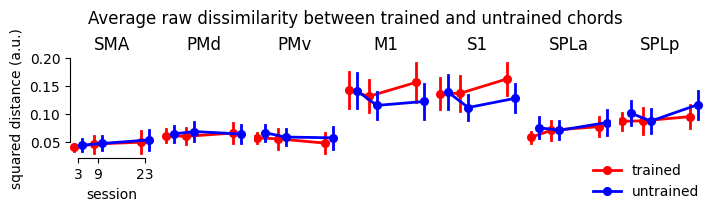

In [4]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, diff_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('squared distance (a.u.)')

fig.suptitle('Average raw dissimilarity between trained and untrained chords')

ttest = ttest_im_sess(diff_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order)
ttest['regionname'] = pd.Categorical(ttest.roi, categories=gl.rois[atlas], ordered=True)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()

In [5]:
# fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

# plot_im_sess(fig, axs, betas, rois, y='MD', hue='metric', x=None, kind='point', estimator='mean', dodge=.4, add_zero=False)

# sb.despine(ax=axs[0], trim=True)
# axs[0].set_xticks([])
# axs[-1].legend([], frameon=False, loc='upper right')
# fig.legend(frameon=False, loc='lower right',)

# axs[0].set_ylabel('squared distance (a.u.)')

# fig.suptitle('Average coefficients for mean deviation')

# print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

# plt.show()

           T  dof     p_val             CI95   roi  session
0  -0.391490   13  0.701777  [-0.019, 0.013]   SMA        3
3  -0.508049   13  0.619930  [-0.019, 0.012]   PMd        3
6  -0.704354   13  0.493638   [-0.039, 0.02]   PMv        3
9  -0.101633   13  0.920599   [-0.05, 0.046]    M1        3
12 -0.129747   13  0.898753  [-0.037, 0.033]    S1        3
15 -1.132510   13  0.277877  [-0.042, 0.013]  SPLa        3
18 -0.939571   13  0.364568  [-0.041, 0.016]  SPLp        3
7  -0.561449   13  0.584041  [-0.042, 0.025]   PMv        9
13  0.853594   13  0.408783  [-0.028, 0.064]    S1        9
10  0.370566   13  0.716929   [-0.04, 0.057]    M1        9
4  -0.986742   13  0.341779  [-0.039, 0.015]   PMd        9
1  -0.435827   13  0.670112  [-0.029, 0.019]   SMA        9
16 -0.137339   13  0.892867  [-0.032, 0.028]  SPLa        9
19 -0.082660   13  0.935381   [-0.032, 0.03]  SPLp        9
5   1.302746   13  0.215267  [-0.005, 0.021]   PMd       23
2   0.445148   13  0.663535  [-0.008, 0.

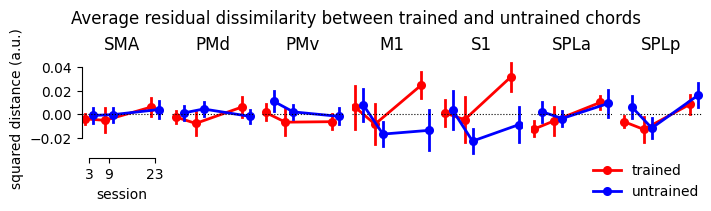

In [6]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, diff_chord_sess, rois, y='crossnobis_res', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('squared distance (a.u.)')

fig.suptitle('Average residual dissimilarity between trained and untrained chords')

ttest = ttest_im_sess(diff_chord_sess, rois, y='crossnobis_res', x='session', hue='chord', hue_order=hue_order)
ttest['regionname'] = pd.Categorical(ttest.roi, categories=gl.rois[atlas], ordered=True)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()

           T  dof     p_val             CI95   roi  session
0   0.142232   13  0.889078   [-0.052, 0.06]   SMA        3
3   0.078685   13  0.938482  [-0.042, 0.045]   PMd        3
6  -0.536437   13  0.600716  [-0.068, 0.041]   PMv        3
9  -0.099567   13  0.922207  [-0.057, 0.052]    M1        3
12  0.177813   13  0.861611   [-0.042, 0.05]    S1        3
15 -0.455846   13  0.656022  [-0.067, 0.044]  SPLa        3
18 -0.733229   13  0.476434  [-0.062, 0.031]  SPLp        3
7  -0.184918   13  0.856147   [-0.059, 0.05]   PMv        9
13  1.245314   13  0.234996   [-0.021, 0.08]    S1        9
10  0.367177   13  0.719395  [-0.036, 0.051]    M1        9
4  -0.036068   13  0.971776  [-0.038, 0.037]   PMd        9
1  -1.321839   13  0.209011  [-0.066, 0.016]   SMA        9
16  0.774825   13  0.452307  [-0.029, 0.061]  SPLa        9
19  0.523452   13  0.609467  [-0.025, 0.041]  SPLp        9
5   1.263555   13  0.228580  [-0.013, 0.051]   PMd       23
2  -0.208062   13  0.838405   [-0.07, 0.

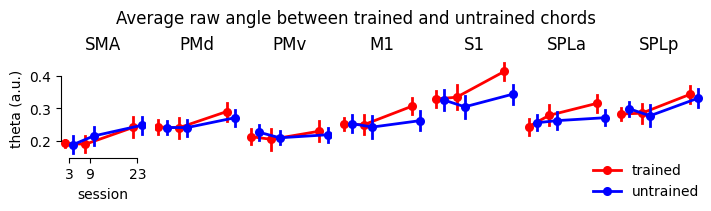

In [7]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, diff_chord_sess, rois, y='theta', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('theta (a.u.)')

fig.suptitle('Average raw angle between trained and untrained chords')

ttest = ttest_im_sess(diff_chord_sess, rois, y='theta', x='session', hue='chord', hue_order=hue_order)
ttest['regionname'] = pd.Categorical(ttest.roi, categories=gl.rois[atlas], ordered=True)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()

           T  dof     p_val             CI95   roi  session
0   0.172458   13  0.865734  [-0.052, 0.061]   SMA        3
3   0.133383   13  0.895933  [-0.042, 0.047]   PMd        3
6  -0.382186   13  0.708498  [-0.067, 0.047]   PMv        3
9  -0.081812   13  0.936043   [-0.054, 0.05]    M1        3
12  0.368216   13  0.718638  [-0.039, 0.056]    S1        3
15 -0.450023   13  0.660107  [-0.065, 0.042]  SPLa        3
18 -0.734092   13  0.475926    [-0.06, 0.03]  SPLp        3
7  -0.484011   13  0.636429  [-0.067, 0.042]   PMv        9
13  0.797501   13  0.439484   [-0.032, 0.07]    S1        9
10  0.021239   13  0.983377  [-0.046, 0.047]    M1        9
4  -0.150254   13  0.882871  [-0.045, 0.039]   PMd        9
1  -1.554899   13  0.143970  [-0.067, 0.011]   SMA        9
16  0.583408   13  0.569603  [-0.033, 0.058]  SPLa        9
19  0.686864   13  0.504237   [-0.02, 0.039]  SPLp        9
5   2.086282   13  0.057218  [-0.001, 0.059]   PMd       23
2   0.304146   13  0.765831   [-0.05, 0.

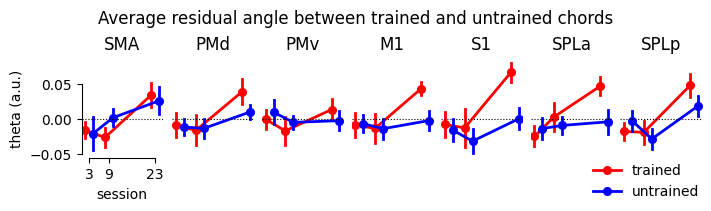

In [8]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, diff_chord_sess, rois, y='theta_res', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('theta (a.u.)')

fig.suptitle('Average residual angle between trained and untrained chords')

ttest = ttest_im_sess(diff_chord_sess, rois, y='theta_res', x='session', hue='chord', hue_order=hue_order)
ttest['regionname'] = pd.Categorical(ttest.roi, categories=gl.rois[atlas], ordered=True)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()